# Notebook 03 — Feature Engineering & Advanced EDA

**Goal:** Derive meaningful features from raw columns, then visualise how they relate to house prices.

| New Feature | Formula | Intuition |
|---|---|---|
| `rooms_per_household` | total_rooms / households | Average rooms per home |
| `bedrooms_per_room` | total_bedrooms / total_rooms | Bedroom ratio |
| `population_per_household` | population / households | Household density |
| `income_category` | pd.cut(median_income, 5) | Binned income tier |

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Consistent presentation style ──────────────────────────────────────────
PALETTE   = 'viridis'
CAT_PAL   = 'Set2'
FIG_DPI   = 150
TITLE_FS  = 14
LABEL_FS  = 12

sns.set_theme(style='whitegrid', palette=CAT_PAL, font_scale=1.1)
plt.rcParams.update({'figure.dpi': FIG_DPI, 'savefig.bbox': 'tight'})

# ── Load data ───────────────────────────────────────────────────────────────
df = pd.read_csv('../../data/raw/housing.csv')
df = df.dropna().reset_index(drop=True)
print(f'Dataset shape after dropping NaN rows: {df.shape}')
df.head(3)

Dataset shape after dropping NaN rows: (20433, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


## 1 · Derive New Features

In [23]:
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

# Income category (5 equal-width bins)
df['income_category'] = pd.cut(
    df['median_income'],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=['Very Low','Low','Medium','High','Very High']
)

DERIVED = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
print(df[DERIVED].describe().round(3))

       rooms_per_household  bedrooms_per_room  population_per_household
count            20433.000          20433.000                 20433.000
mean                 5.431              0.213                     3.072
std                  2.483              0.058                    10.438
min                  0.846              0.100                     0.692
25%                  4.441              0.175                     2.429
50%                  5.231              0.203                     2.818
75%                  6.052              0.240                     3.282
max                141.909              1.000                  1243.333


---
### 📊 PLOT 1 — Distribution of Derived Features
**What it shows:** Histograms + KDE curves for the three engineered ratio features.  
**Presentation use:** Demonstrates that raw counts become more informative per-household metrics; highlight the right-skew in `population_per_household` (outlier districts).

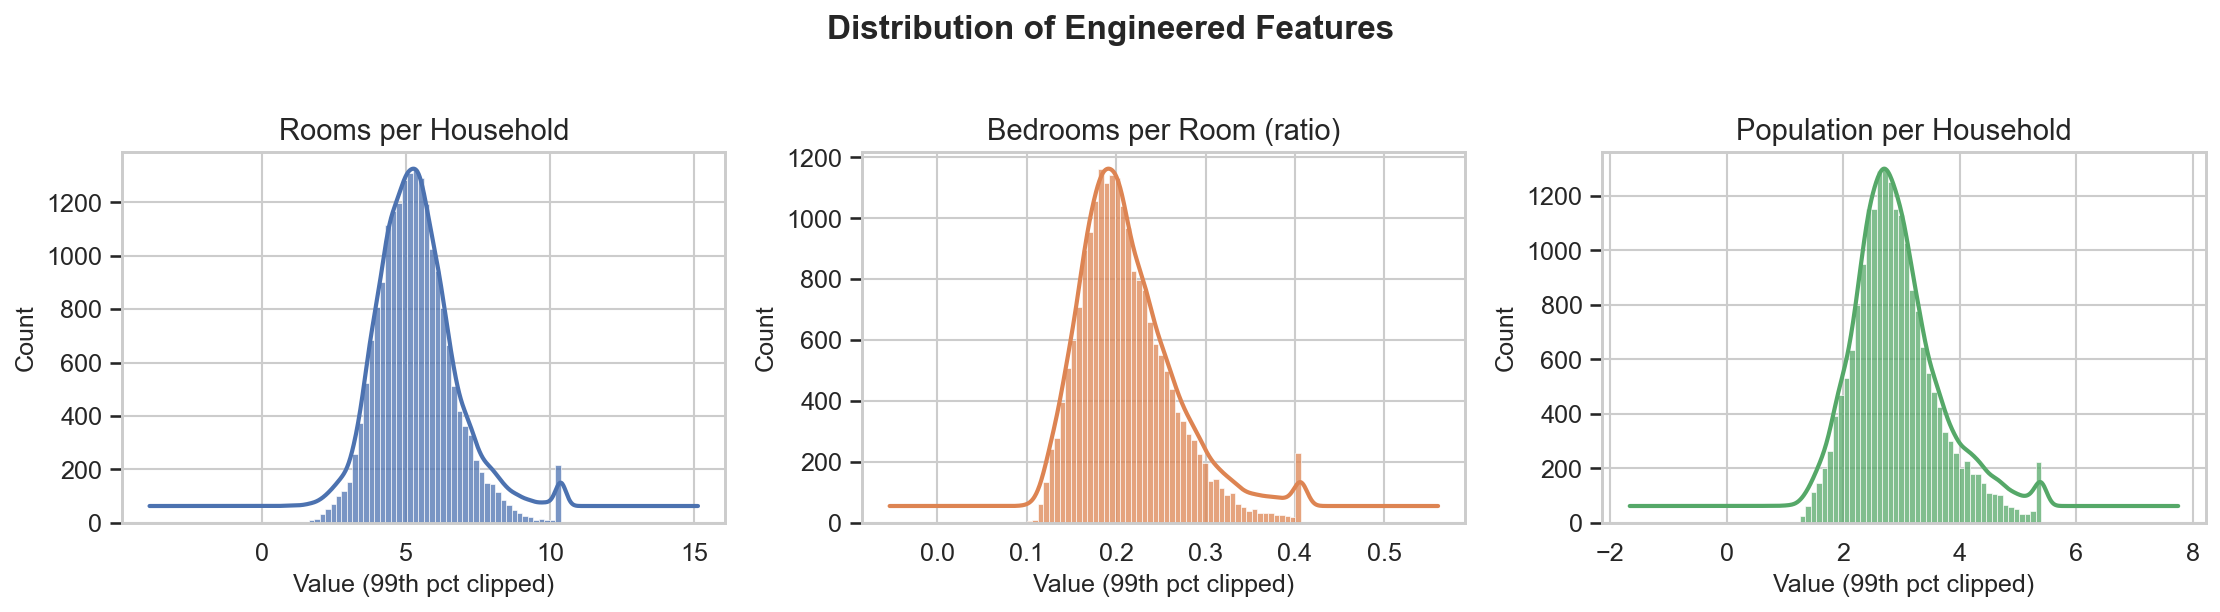

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = [
    'Rooms per Household',
    'Bedrooms per Room (ratio)',
    'Population per Household'
]
colors = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, title, c in zip(axes, DERIVED, titles, colors):
    clipped = df[col].clip(upper=df[col].quantile(0.99))   # clip top 1% for readability
    ax.hist(clipped, bins=50, color=c, alpha=0.75, edgecolor='white', linewidth=0.4)
    ax2 = ax.twinx()
    clipped.plot.kde(ax=ax2, color=c, linewidth=2)
    ax2.set_ylabel('')
    ax2.set_yticks([])
    ax.set_title(title, fontsize=TITLE_FS)
    ax.set_xlabel('Value (99th pct clipped)', fontsize=LABEL_FS)
    ax.set_ylabel('Count', fontsize=LABEL_FS)

fig.suptitle('Distribution of Engineered Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_01_derived_distributions.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 2 — Correlation Heatmap: All Features (Original + Engineered)
**What it shows:** Pearson correlation coefficients between every numeric feature and `median_house_value`.  
**Presentation use:** Show that `median_income` is the single strongest predictor; the new feature `bedrooms_per_room` has a meaningful negative correlation that raw `total_bedrooms` did not capture alone.

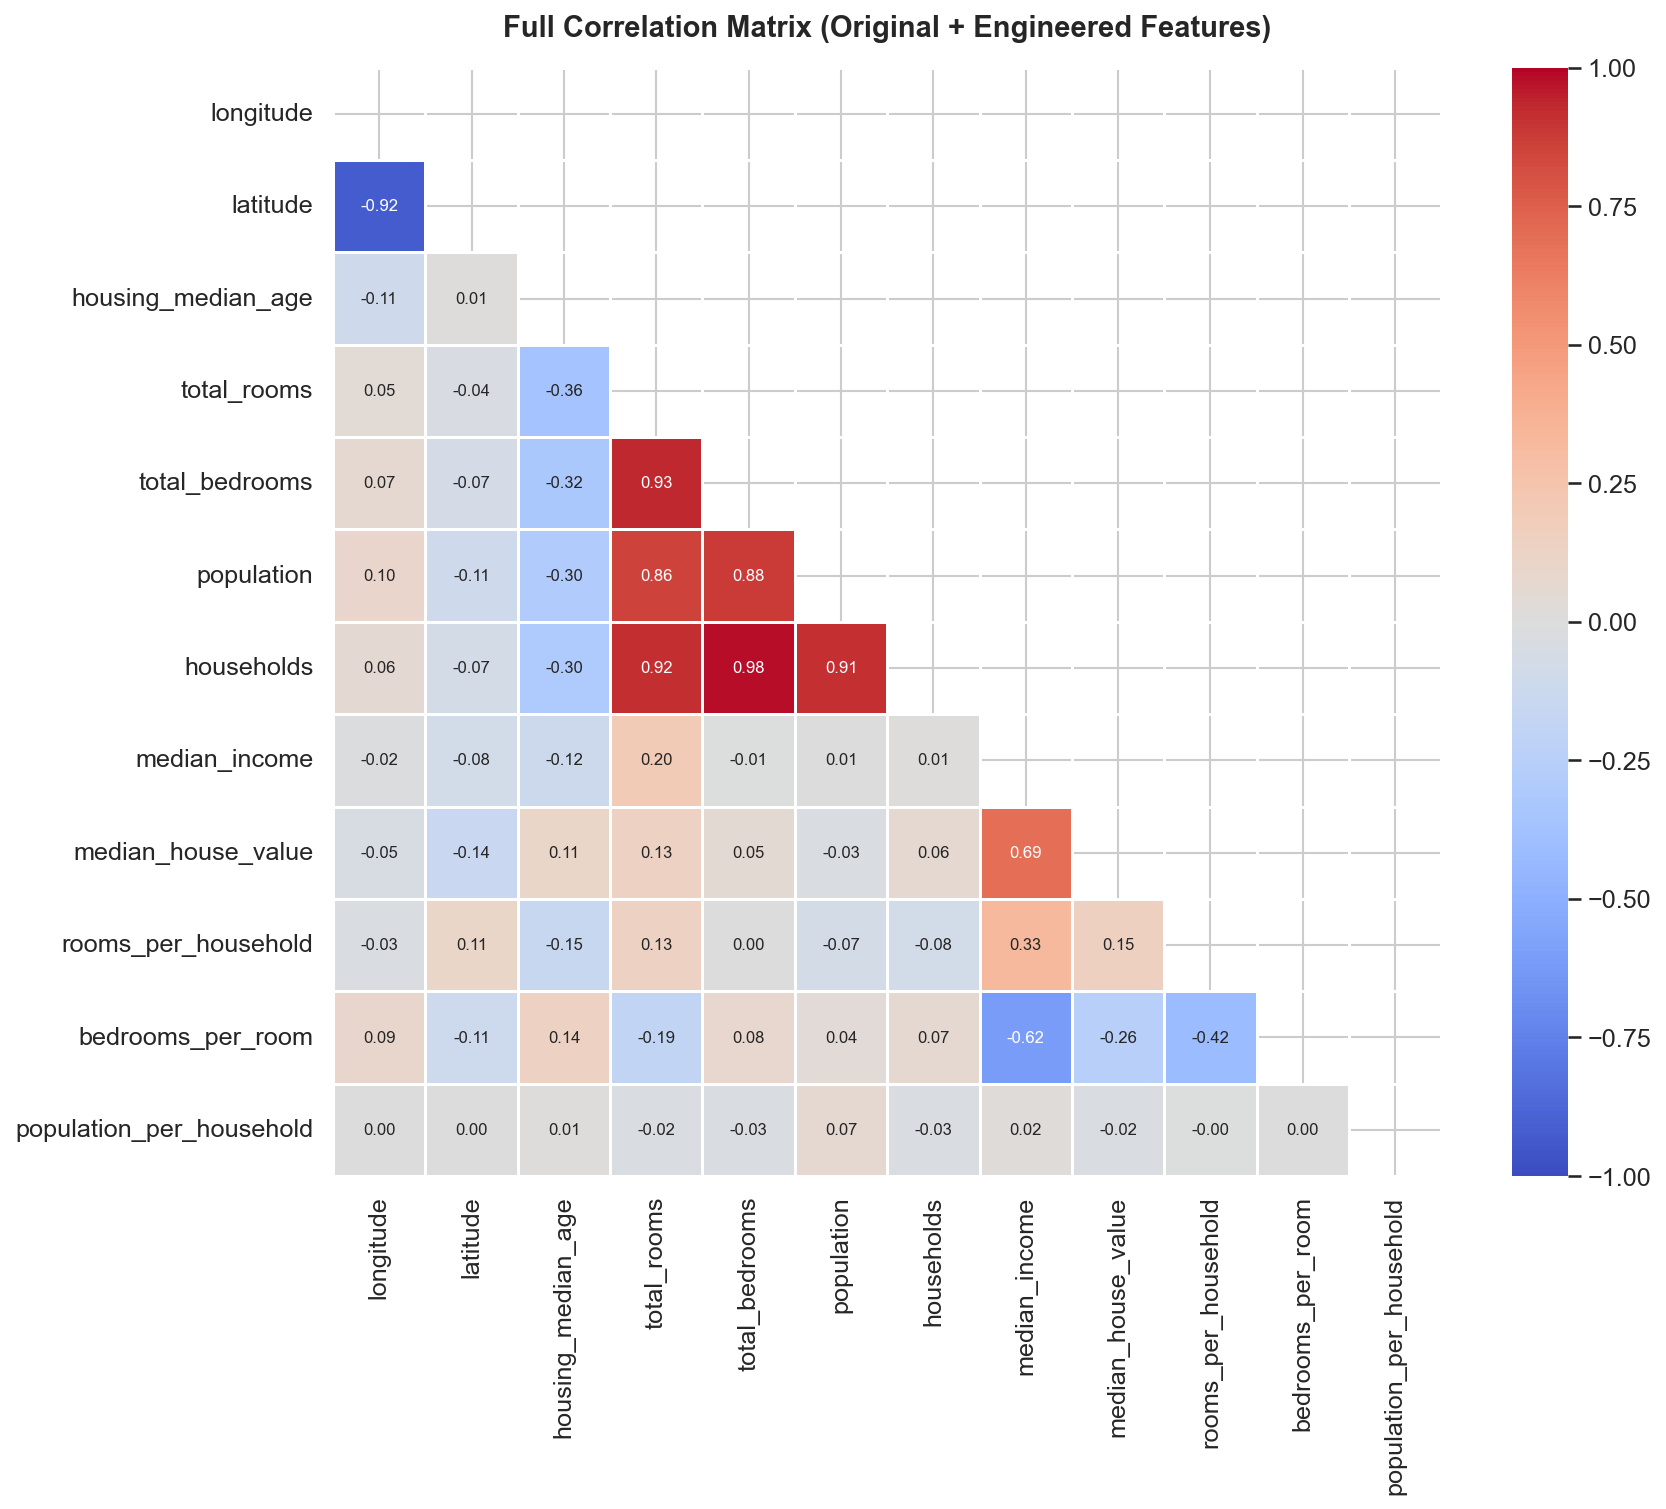

In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Full Correlation Matrix (Original + Engineered Features)',
             fontsize=TITLE_FS, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_02_full_correlation_heatmap.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 3 — Top Feature Correlations with Target (Bar Chart)
**What it shows:** Sorted horizontal bar of each feature's Pearson correlation with `median_house_value`.  
**Presentation use:** Quick, clean slide showing which features matter most — great for model motivation slides.

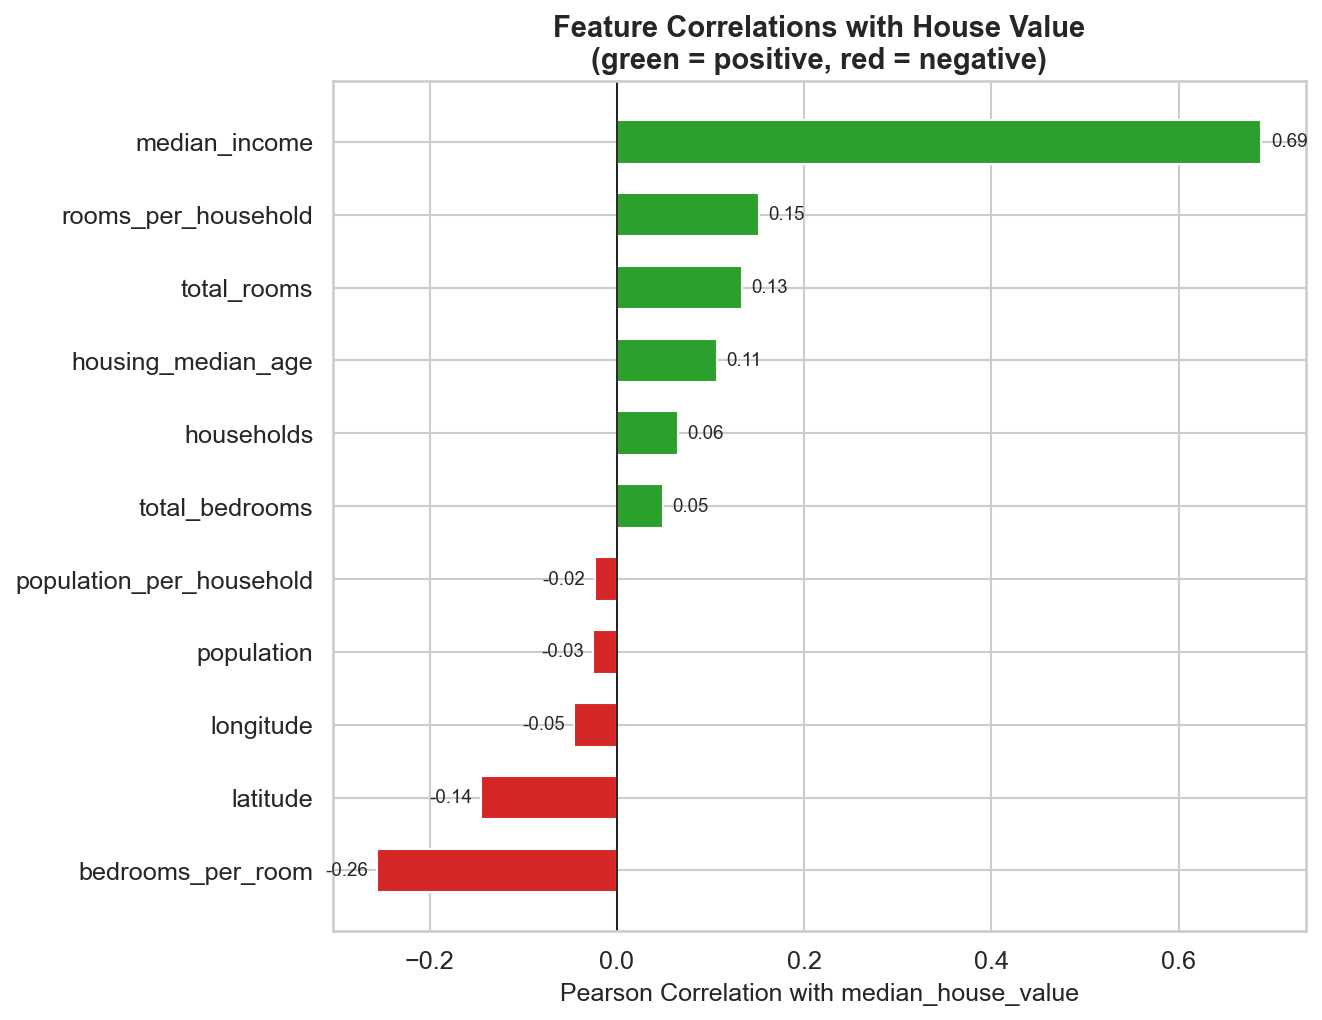

In [26]:
target_corr = corr['median_house_value'].drop('median_house_value').sort_values()

colors_bar = ['#d62728' if v < 0 else '#2ca02c' for v in target_corr]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with median_house_value', fontsize=LABEL_FS)
ax.set_title('Feature Correlations with House Value\n(green = positive, red = negative)',
             fontsize=TITLE_FS, fontweight='bold')
for bar, val in zip(bars, target_corr.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', ha=ha, fontsize=9)
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_03_target_correlations.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 4 — Median House Value by Income Category
**What it shows:** Box plots of house value across five income tiers.  
**Presentation use:** Visually confirms the income–price relationship is monotonic and strong; each income tier is a distinct price band — supports using `median_income` as a key feature.

C:\Users\TDV\AppData\Local\Temp\ipykernel_33136\1025468265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


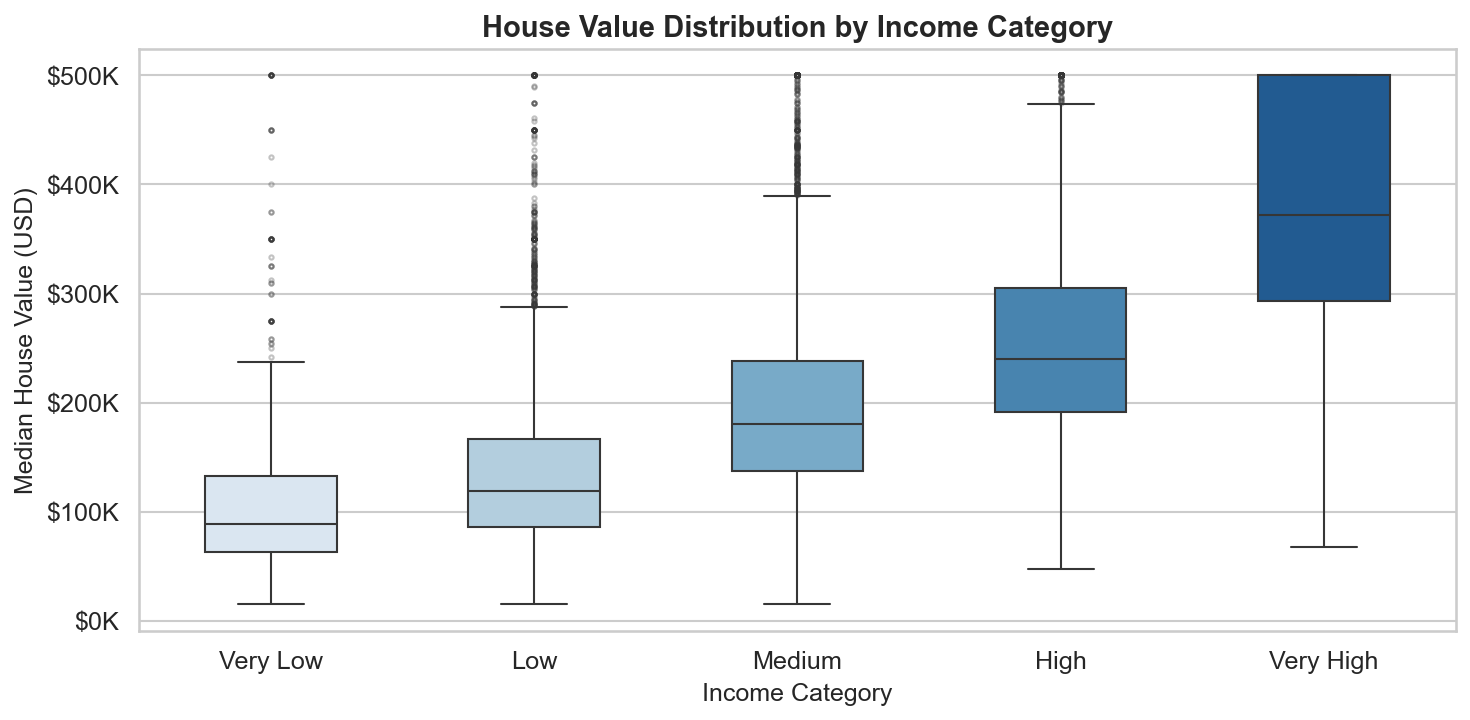

In [27]:
order = ['Very Low','Low','Medium','High','Very High']
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=df, x='income_category', y='median_house_value',
    order=order, palette='Blues', ax=ax, width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_xlabel('Income Category', fontsize=LABEL_FS)
ax.set_ylabel('Median House Value (USD)', fontsize=LABEL_FS)
ax.set_title('House Value Distribution by Income Category',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_04_value_by_income_category.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 5 — Boxplots of All Numeric Features by Ocean Proximity
**What it shows:** One box-plot panel per feature, split by `ocean_proximity` category.  
**Presentation use:** Reveals geographic segmentation — island and near-bay districts differ substantially on most features.

C:\Users\TDV\AppData\Local\Temp\ipykernel_33136\802892700.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\TDV\AppData\Local\Temp\ipykernel_33136\802892700.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\TDV\AppData\Local\Temp\ipykernel_33136\802892700.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\TDV\AppData\Local\Temp\ipykernel_33136\802892700.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

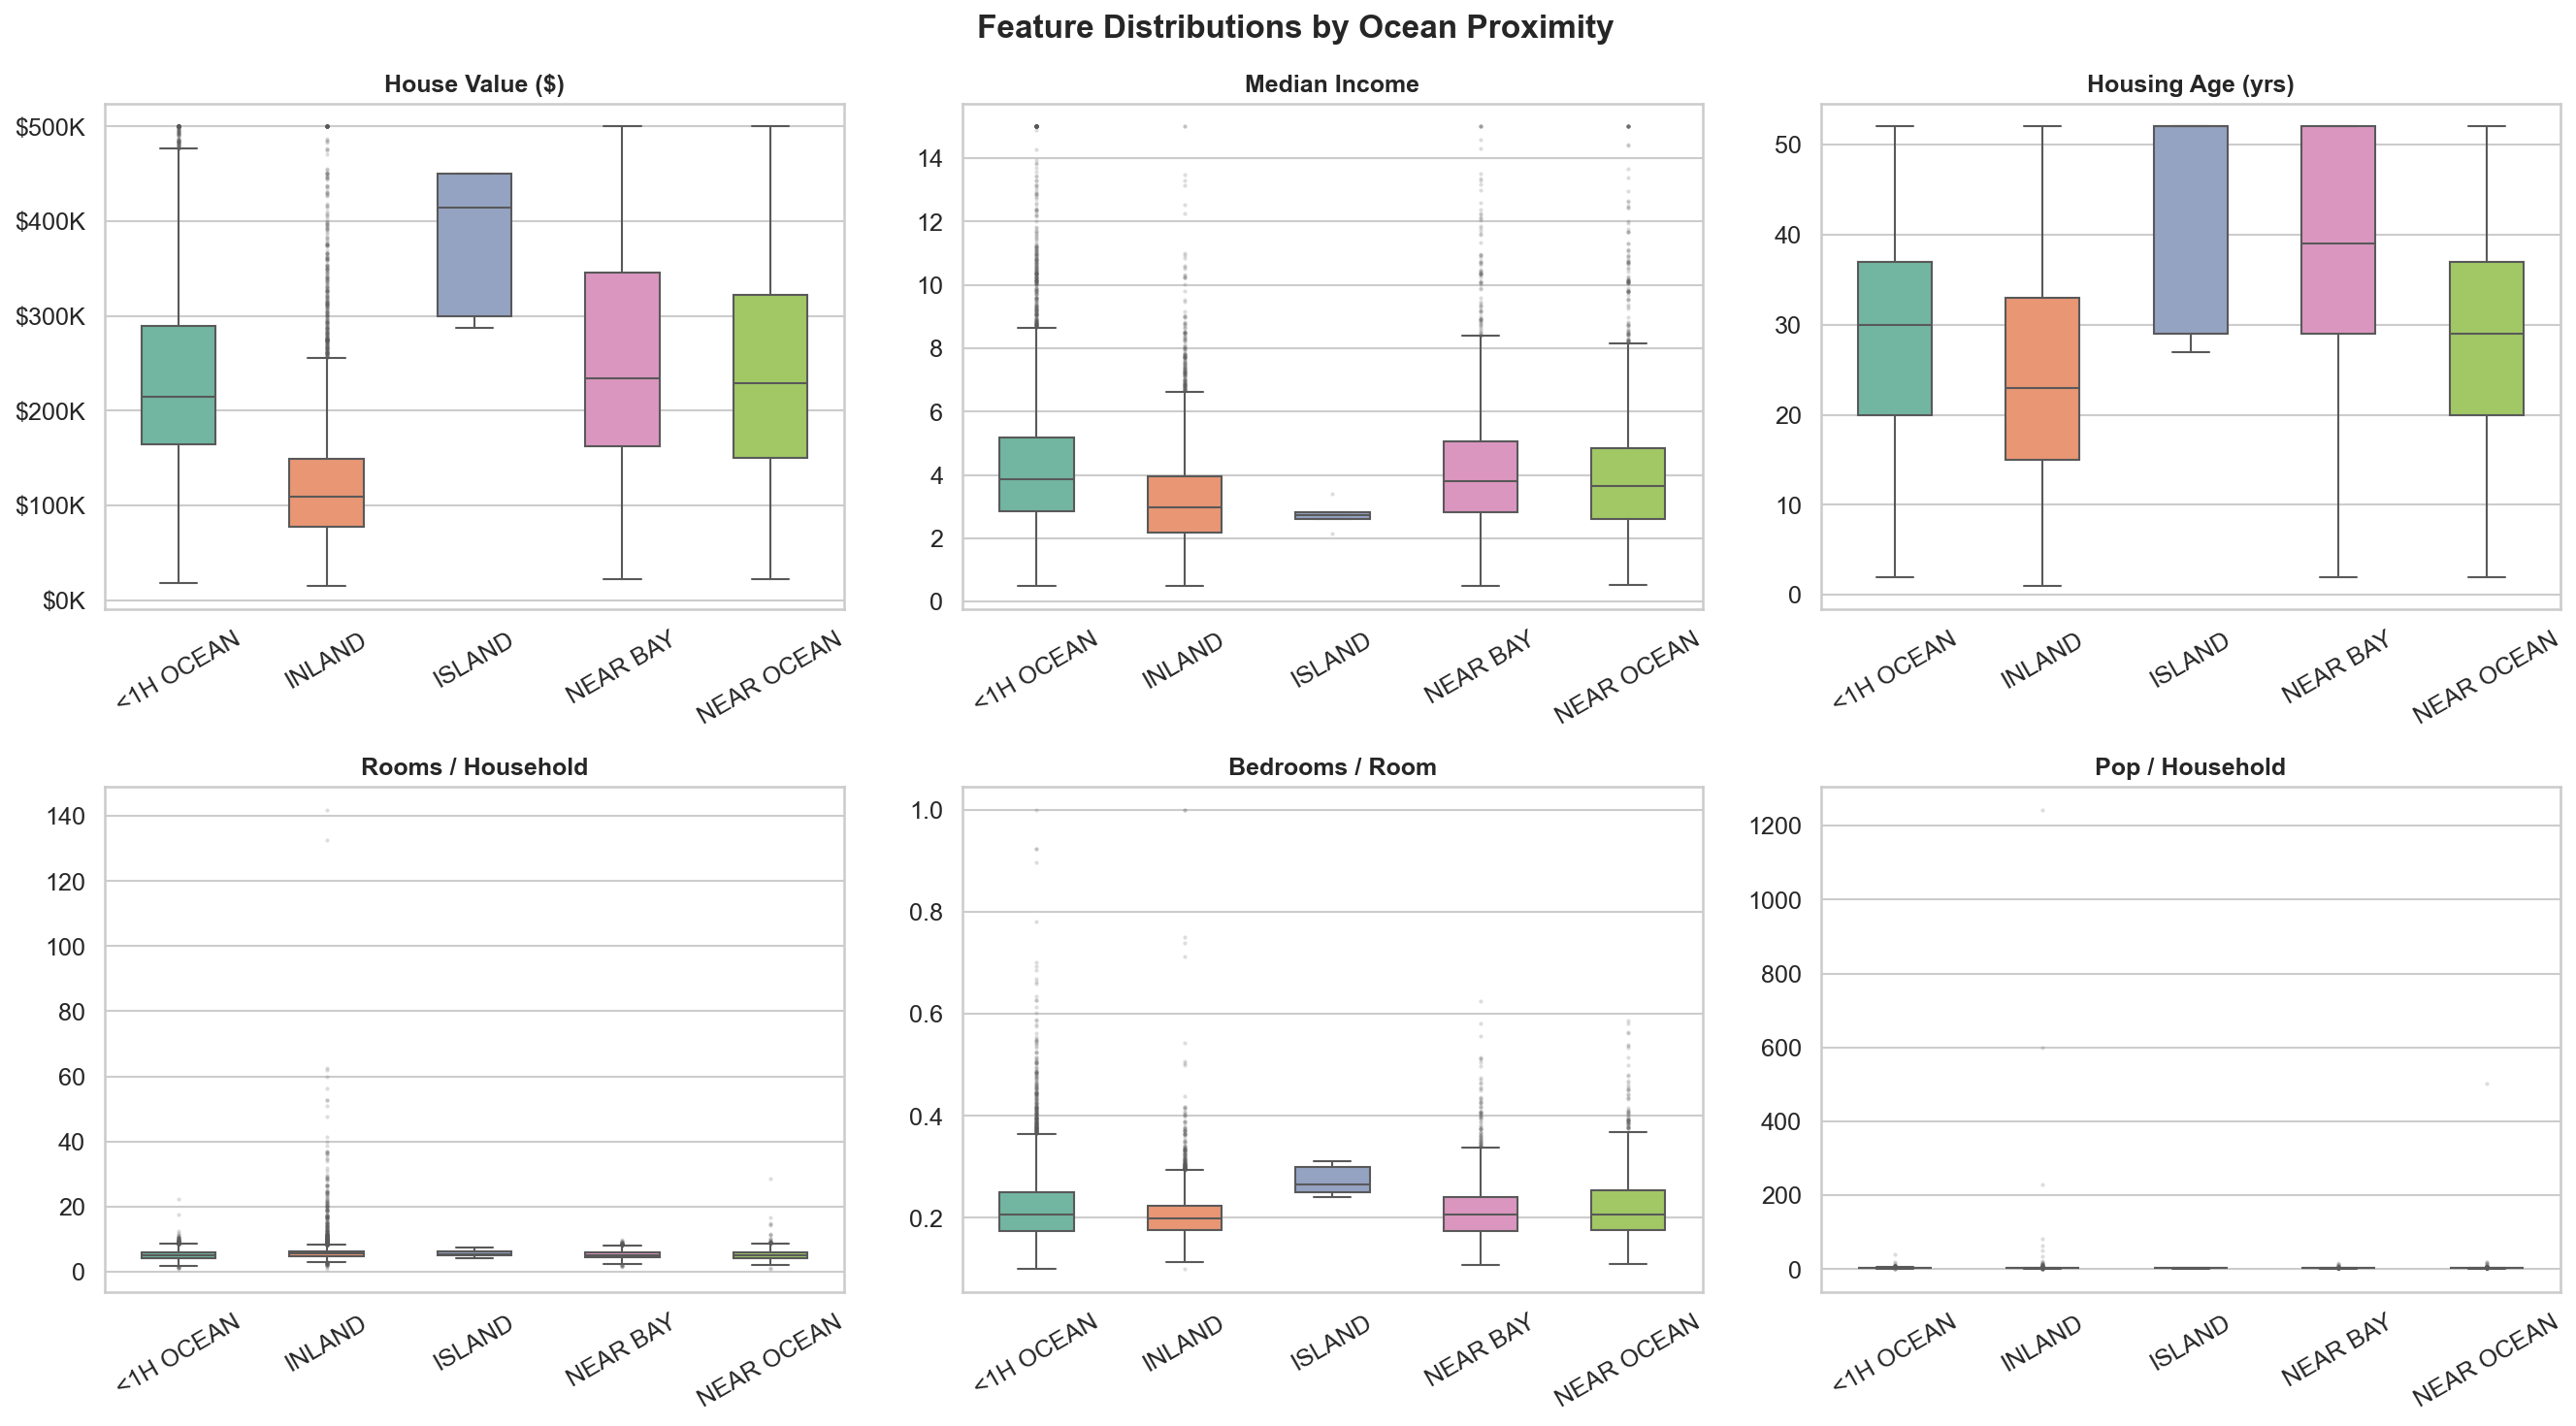

In [28]:
plot_features = [
    'median_house_value','median_income','housing_median_age',
    'rooms_per_household','bedrooms_per_room','population_per_household'
]
nice_labels = {
    'median_house_value': 'House Value ($)',
    'median_income': 'Median Income',
    'housing_median_age': 'Housing Age (yrs)',
    'rooms_per_household': 'Rooms / Household',
    'bedrooms_per_room': 'Bedrooms / Room',
    'population_per_household': 'Pop / Household'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
prox_order = sorted(df['ocean_proximity'].unique())

for ax, feat in zip(axes.flat, plot_features):
    sns.boxplot(
        data=df, x='ocean_proximity', y=feat,
        order=prox_order, palette=CAT_PAL, ax=ax, width=0.5,
        flierprops=dict(marker='.', markersize=2, alpha=0.2)
    )
    ax.set_title(nice_labels[feat], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30)
    if feat == 'median_house_value':
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))

fig.suptitle('Feature Distributions by Ocean Proximity', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_05_features_by_ocean_proximity.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 6 — Pairplot: Key Features Coloured by Income Category
**What it shows:** Scatter-matrix of the five most important features, coloured by income tier.  
**Presentation use:** Shows multivariate separation between income groups; the `median_income` vs `median_house_value` diagonal clearly separates the clusters.

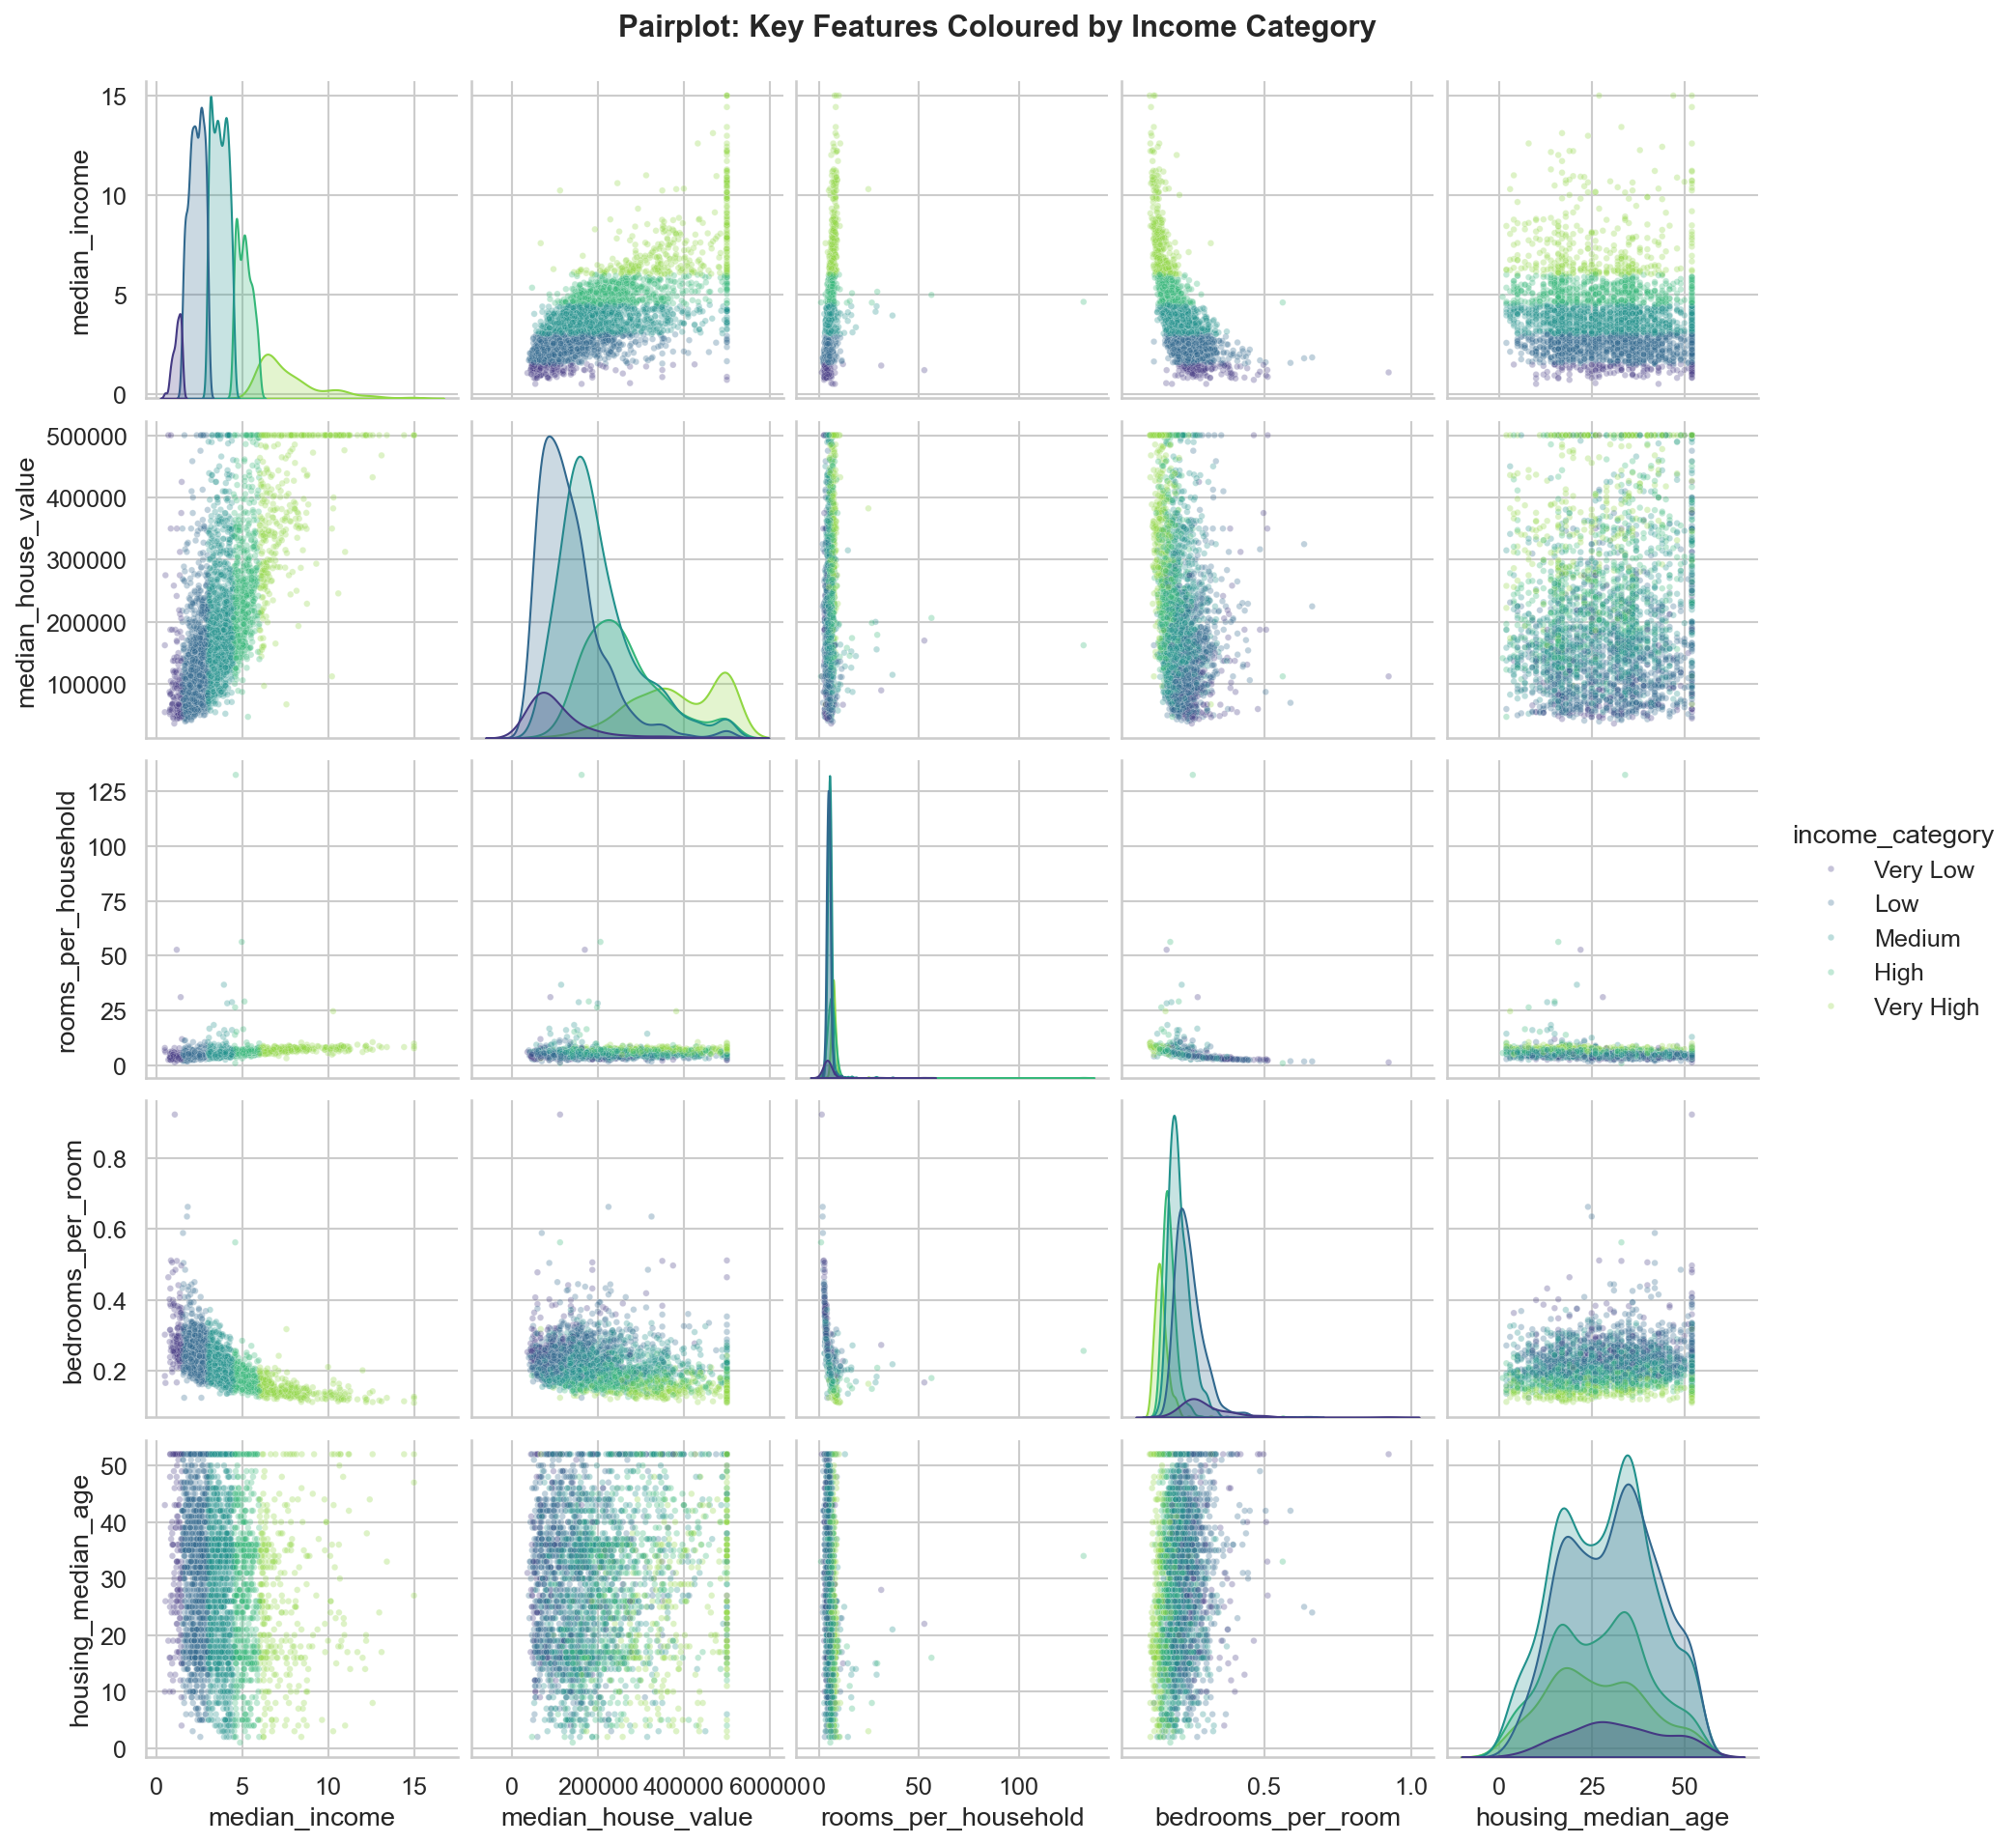

In [29]:
pair_cols = ['median_income','median_house_value',
             'rooms_per_household','bedrooms_per_room',
             'housing_median_age','income_category']

sample = df[pair_cols].dropna().sample(3000, random_state=42)
pg = sns.pairplot(
    sample, hue='income_category',
    hue_order=['Very Low','Low','Medium','High','Very High'],
    vars=pair_cols[:-1],
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde',
    palette='viridis'
)
pg.figure.suptitle('Pairplot: Key Features Coloured by Income Category',
                   y=1.02, fontsize=15, fontweight='bold')
pg.figure.savefig('../../data/visualize/plot03_06_pairplot_income.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

---
### 📊 PLOT 7 — Median House Value vs Rooms per Household (scatter + regression)
**What it shows:** Scatter of the engineered `rooms_per_household` vs house value with a regression line, coloured by income category.  
**Presentation use:** Highlights that engineered features add explanatory power beyond raw counts.

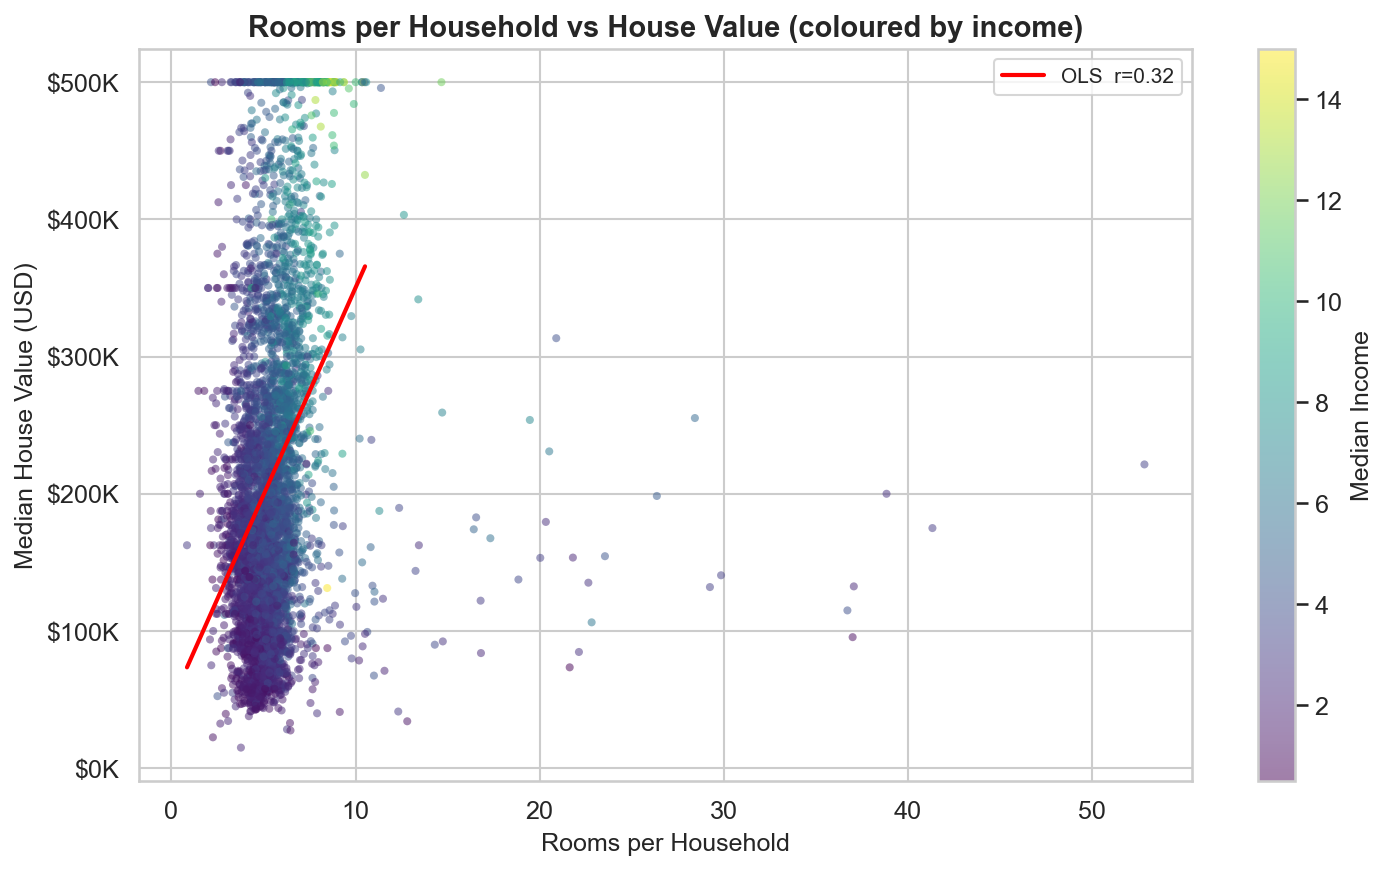

In [30]:
sample2 = df.dropna().sample(5000, random_state=0)
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    sample2['rooms_per_household'],
    sample2['median_house_value'],
    c=sample2['median_income'], cmap=PALETTE,
    alpha=0.5, s=15, edgecolors='none'
)
# OLS regression line
clipped = sample2[sample2['rooms_per_household'] < sample2['rooms_per_household'].quantile(0.99)]
m, b, r, p, _ = stats.linregress(clipped['rooms_per_household'], clipped['median_house_value'])
x_line = np.linspace(clipped['rooms_per_household'].min(), clipped['rooms_per_household'].max(), 200)
ax.plot(x_line, m*x_line + b, color='red', linewidth=2, label=f'OLS  r={r:.2f}')
ax.legend(fontsize=10)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Median Income', fontsize=LABEL_FS)
ax.set_xlabel('Rooms per Household', fontsize=LABEL_FS)
ax.set_ylabel('Median House Value (USD)', fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Rooms per Household vs House Value (coloured by income)',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_07_rooms_vs_value.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 8 — Violin Plot: Housing Age Distribution by Ocean Proximity
**What it shows:** Violin plots of `housing_median_age` across location categories, with embedded boxplot.  
**Presentation use:** Shows that island and near-ocean districts tend to have older housing stock — useful context for pricing differences.

C:\Users\TDV\AppData\Local\Temp\ipykernel_33136\2631530099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


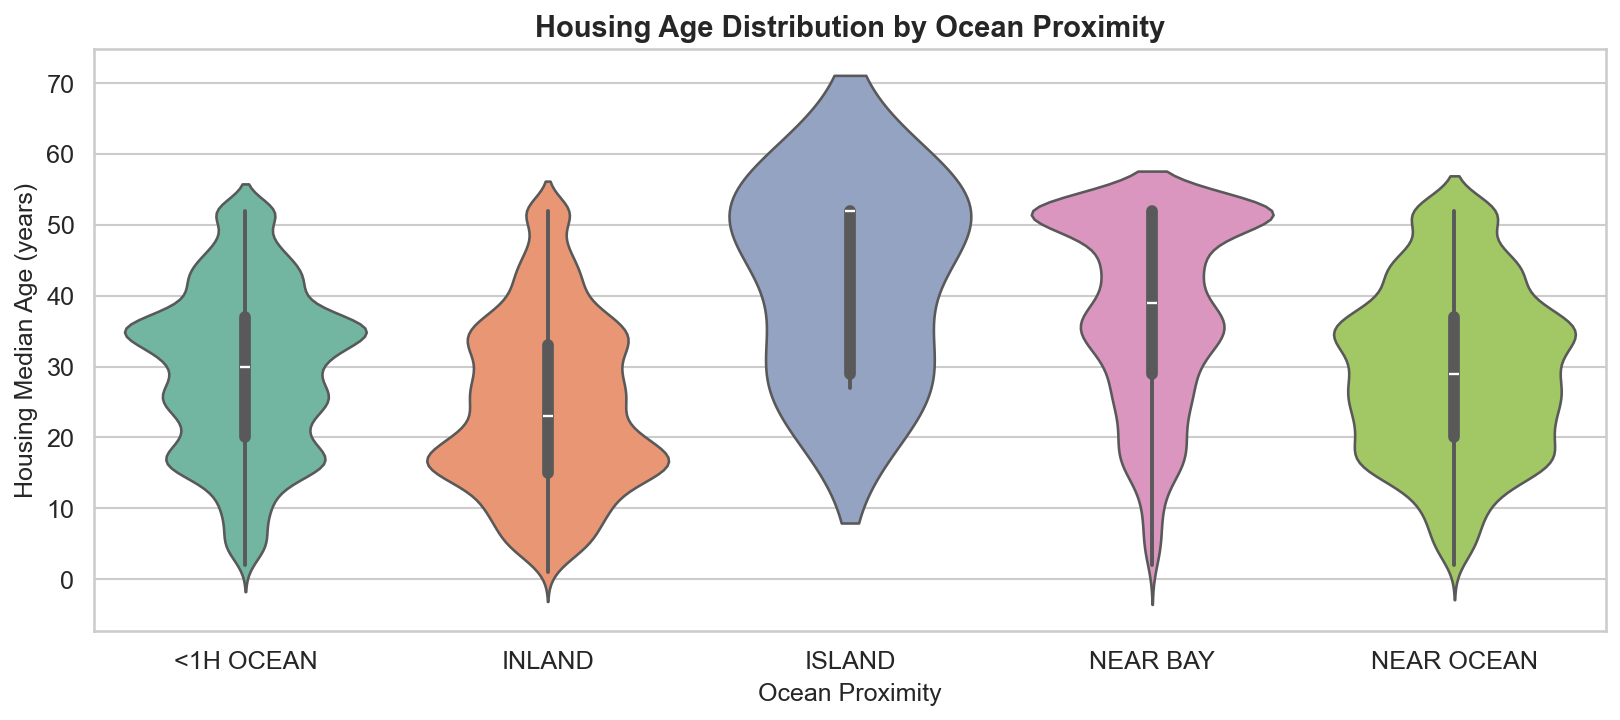

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(
    data=df, x='ocean_proximity', y='housing_median_age',
    order=prox_order, palette=CAT_PAL,
    inner='box', ax=ax
)
ax.set_xlabel('Ocean Proximity', fontsize=LABEL_FS)
ax.set_ylabel('Housing Median Age (years)', fontsize=LABEL_FS)
ax.set_title('Housing Age Distribution by Ocean Proximity',
             fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_08_age_violin.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 9 — Stacked Bar: Ocean Proximity Counts by Income Category
**What it shows:** What share of each income tier lives in each ocean-proximity zone.  
**Presentation use:** Shows "who lives where" — higher income categories are more concentrated in near-bay / near-ocean areas.

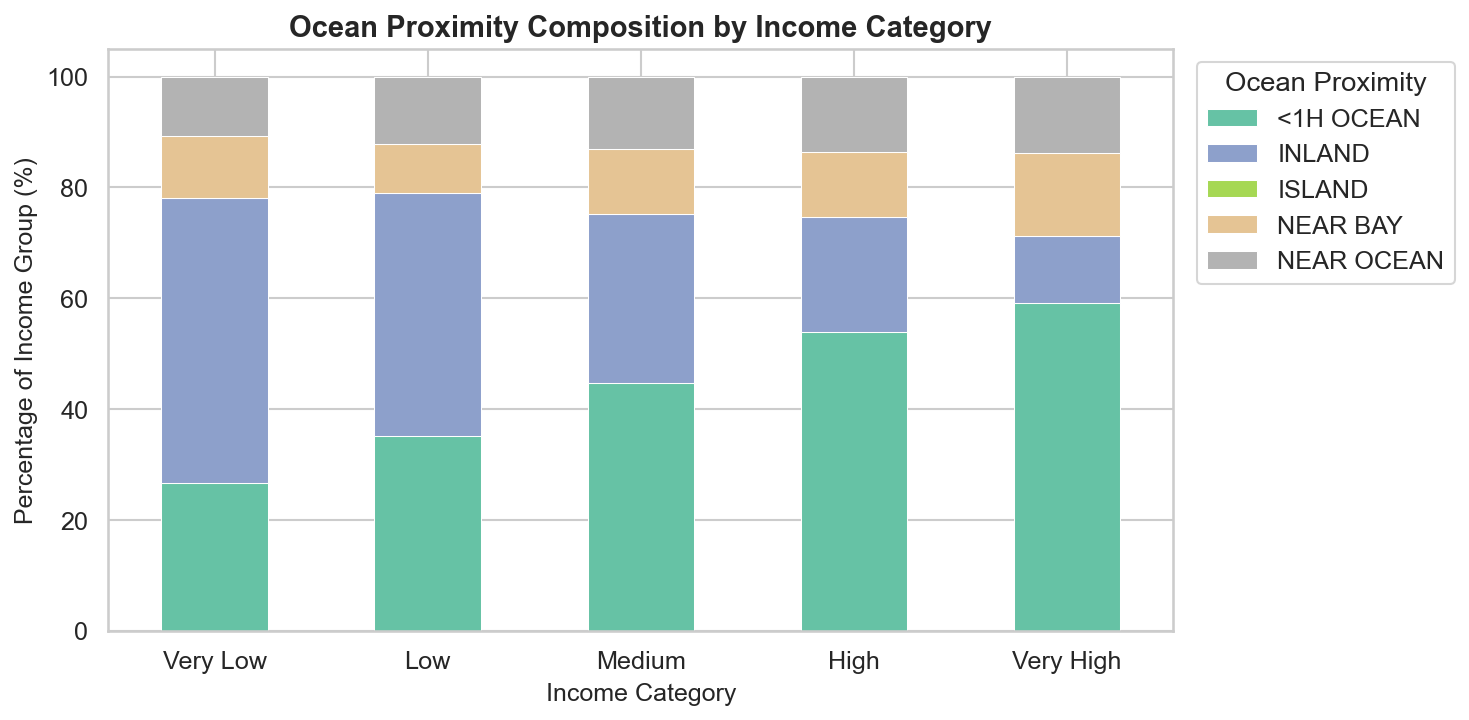

In [32]:
ct = pd.crosstab(df['income_category'], df['ocean_proximity'], normalize='index') * 100
ct = ct.loc[['Very Low','Low','Medium','High','Very High']]

fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', stacked=True, colormap=CAT_PAL, ax=ax, edgecolor='white', linewidth=0.5)
ax.set_ylabel('Percentage of Income Group (%)', fontsize=LABEL_FS)
ax.set_xlabel('Income Category', fontsize=LABEL_FS)
ax.set_title('Ocean Proximity Composition by Income Category',
             fontsize=TITLE_FS, fontweight='bold')
ax.legend(title='Ocean Proximity', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_09_stacked_bar_income_proximity.png', dpi=FIG_DPI)
plt.show()

---
### 📊 PLOT 10 — Hexbin: Median Income vs Median House Value
**What it shows:** Density hexbin of the most important feature pair; colour encodes point density.  
**Presentation use:** Cleaner than a scatter for 20 000+ points; clearly shows the strong positive trend and the hard price ceiling at $500 000.

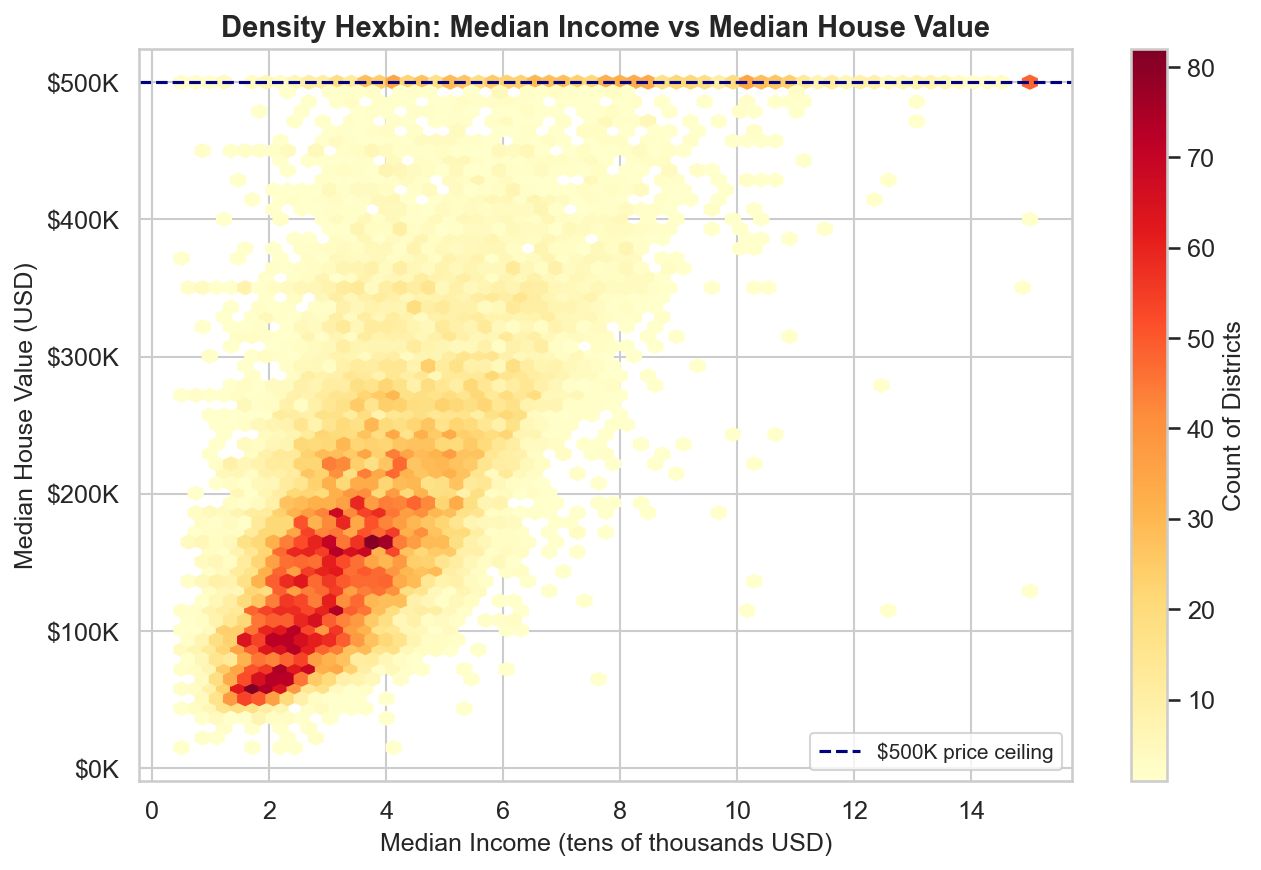

In [33]:
fig, ax = plt.subplots(figsize=(9, 6))
hb = ax.hexbin(
    df['median_income'], df['median_house_value'],
    gridsize=60, cmap='YlOrRd', mincnt=1
)
cbar = fig.colorbar(hb, ax=ax)
cbar.set_label('Count of Districts', fontsize=LABEL_FS)
ax.set_xlabel('Median Income (tens of thousands USD)', fontsize=LABEL_FS)
ax.set_ylabel('Median House Value (USD)', fontsize=LABEL_FS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
ax.set_title('Density Hexbin: Median Income vs Median House Value',
             fontsize=TITLE_FS, fontweight='bold')
ax.axhline(500000, color='navy', linestyle='--', linewidth=1.5, label='$500K price ceiling')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../../data/visualize/plot03_10_hexbin_income_value.png', dpi=FIG_DPI)
plt.show()

---
## Summary of Notebook 03

| Plot | File | Key Takeaway |
|------|------|--------------|
| 1 | plot03_01_derived_distributions | Derived ratios are right-skewed; outlier districts exist |
| 2 | plot03_02_full_correlation_heatmap | `median_income` dominates; `bedrooms_per_room` adds negative signal |
| 3 | plot03_03_target_correlations | Ranked bar view of feature importance before modelling |
| 4 | plot03_04_value_by_income_category | Strong monotonic price–income relationship |
| 5 | plot03_05_features_by_ocean_proximity | Island/near-bay districts are outliers in most features |
| 6 | plot03_06_pairplot_income | Multivariate separation by income tier |
| 7 | plot03_07_rooms_vs_value | Engineered feature shows clear positive trend with value |
| 8 | plot03_08_age_violin | Older housing near coast / island |
| 9 | plot03_09_stacked_bar_income_proximity | High-income groups cluster near water |
| 10 | plot03_10_hexbin_income_value | Dense positive band; hard $500K ceiling artefact visible |